In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

In [2]:
# Load the dataset
file_path = r"C:\Users\Divya\Downloads\adult_data.csv"
data = pd.read_csv(file_path)

In [3]:
# Rename the columns for better understanding
column_names = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 
                'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 
                'hours-per-week', 'native-country', 'income']
data.columns = column_names

# Data Understanding and Cleaning

In [4]:
# Check for missing values
print("Missing values in the dataset:")
print(data.isnull().sum())


Missing values in the dataset:
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


In [5]:
# Basic Statistical Analysis
print("\nBasic statistical analysis for numerical features:")
print(data.describe())



Basic statistical analysis for numerical features:
                age        fnlwgt  education-num  capital-gain  capital-loss  \
count  32560.000000  3.256000e+04   32560.000000  32560.000000  32560.000000   
mean      38.581634  1.897818e+05      10.080590   1077.615172     87.306511   
std       13.640642  1.055498e+05       2.572709   7385.402999    402.966116   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.178315e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.783630e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.370545e+05      12.000000      0.000000      0.000000   
max       90.000000  1.484705e+06      16.000000  99999.000000   4356.000000   

       hours-per-week  
count    32560.000000  
mean        40.437469  
std         12.347618  
min          1.000000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
max         99.000000  


# Exploratory Data Analysis (EDA)

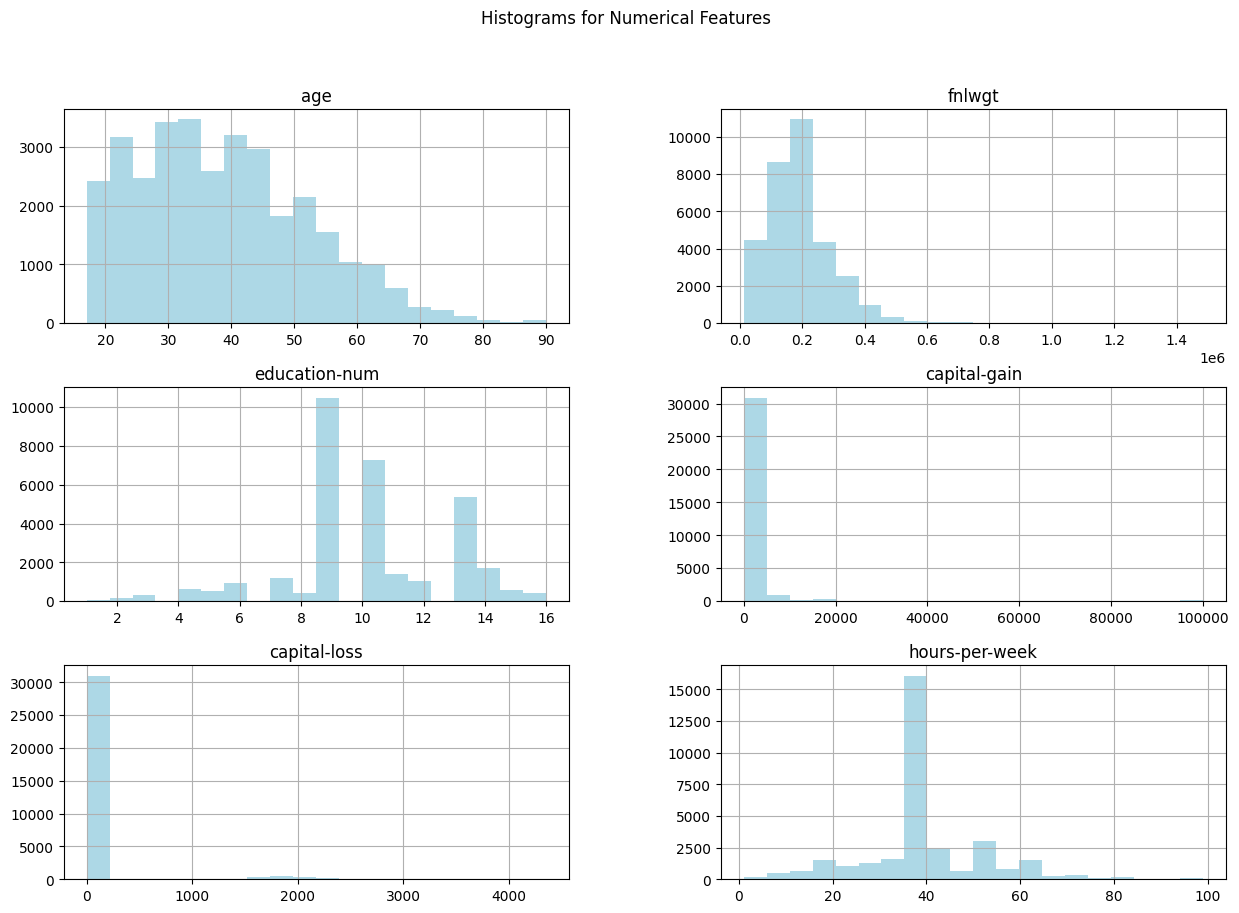

In [6]:

# Plotting histograms for numerical features
data.hist(figsize=(15, 10), bins=20, color='lightblue')
plt.suptitle('Histograms for Numerical Features')
plt.show()

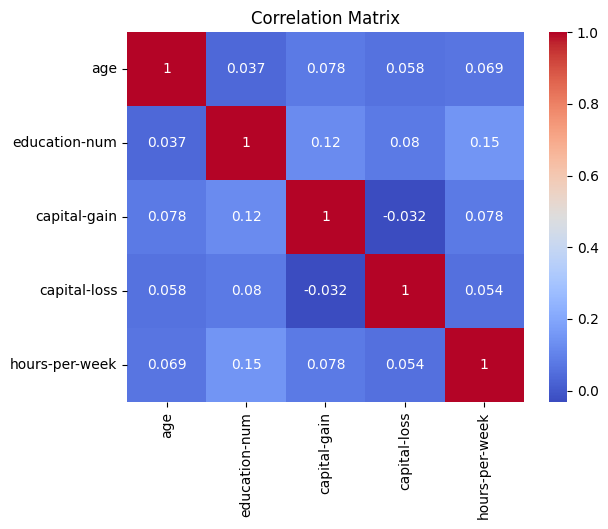

In [7]:
# Correlation matrix
corr_matrix = data[['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

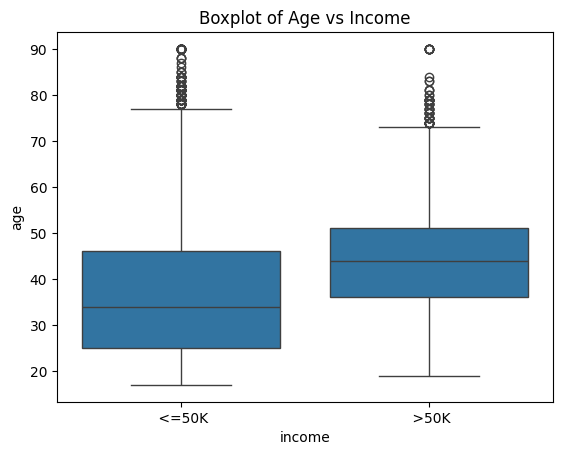

In [8]:
# Box plots for categorical data vs income
sns.boxplot(x='income', y='age', data=data)
plt.title('Boxplot of Age vs Income')
plt.show()

# Feature Engineering

In [9]:
# Encode categorical variables using Label Encoding
label_encoder = LabelEncoder()
categorical_cols = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 
                    'race', 'sex', 'native-country', 'income']

In [10]:
for col in categorical_cols:
    data[col] = label_encoder.fit_transform(data[col])


In [11]:
# Create a new feature: 'income_level' (binary classification: >50K as 1 and <=50K as 0)
data['income_level'] = np.where(data['income'] == 1, 1, 0)

In [12]:
# Drop the old income column
data = data.drop('income', axis=1)

In [13]:
# Scale numerical features
scaler = StandardScaler()
numerical_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
data[numerical_cols] = scaler.fit_transform(data[numerical_cols])

#  Modeling

In [14]:
# Split data into training and testing sets
X = data.drop('income_level', axis=1)
y = data['income_level']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [15]:
# Implement two models: Linear Regression and Decision Tree
# Model 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

In [16]:
# Model 2: Decision Tree
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)


In [17]:
# Evaluation of both models
print("Linear Regression - RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("Linear Regression - R2 Score:", r2_score(y_test, y_pred_lr))


Linear Regression - RMSE: 0.36974735180316015
Linear Regression - R2 Score: 0.2566633780734241


In [18]:
print("Decision Tree - RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))
print("Decision Tree - R2 Score:", r2_score(y_test, y_pred_dt))

Decision Tree - RMSE: 0.43824159096974363
Decision Tree - R2 Score: -0.044245394221160916


# Model Tuning (Decision Tree)

In [19]:
# Hyperparameter tuning using GridSearchCV for Decision Tree
param_grid = {
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 10, 20]
}

In [20]:
grid_search = GridSearchCV(estimator=dt_model, param_grid=param_grid, scoring='neg_mean_squared_error', cv=3)
grid_search.fit(X_train, y_train)


GridSearchCV(cv=3, estimator=DecisionTreeRegressor(random_state=42),
             param_grid={'max_depth': [5, 10, 15],
                         'min_samples_split': [2, 10, 20]},
             scoring='neg_mean_squared_error')

In [21]:
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)


In [22]:
print("Best Decision Tree Model - RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_best)))
print("Best Decision Tree Model - R2 Score:", r2_score(y_test, y_pred_best))

Best Decision Tree Model - RMSE: 0.32148672836216097
Best Decision Tree Model - R2 Score: 0.43804507281643335


# Interpretation & Insights

In [23]:
# Feature Importance
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]

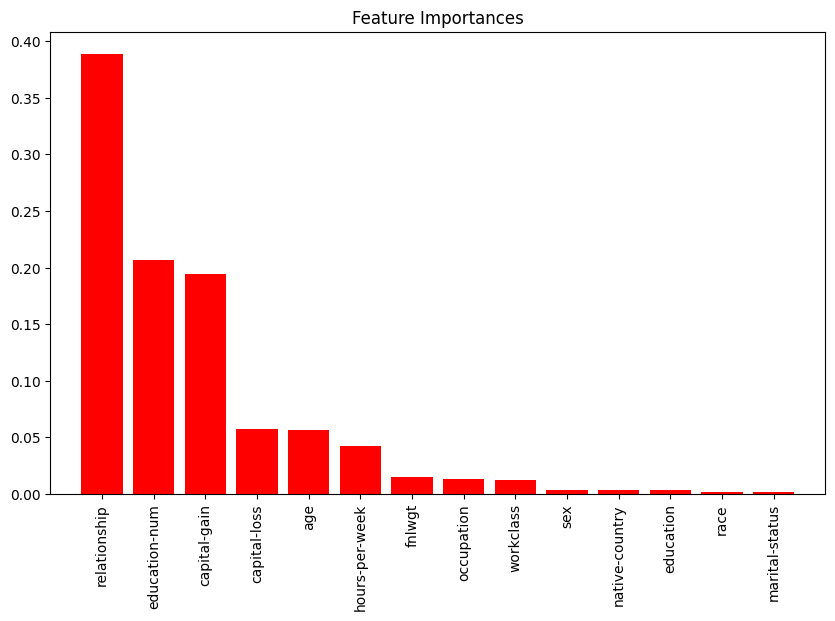

In [24]:
# Plot the feature importance
plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(X_train.shape[1]), importances[indices], color="r", align="center")
plt.xticks(range(X_train.shape[1]), X.columns[indices], rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.show()